# NLP Milestone 2    |    Group 12

## Overview
This notebook documents the data preprocessing and exploratory analysis pipeline for the TL;DR summarization dataset used in our project.

The goal is to transform the raw Reddit data into a clean, structured format suitable for supervised fine-tuning and preference-aligned training (e.g., DPO).
The notebook performs the following main steps:

- Load and inspect the original dataset from Hugging Face (trl-lib/tldr).

- Parse and normalize each post into structured fields (subreddit, title, post_body, gold_tldr, etc.).

- Clean and standardize text content, including demographic tag normalization and de-duplication.

- Generate descriptive statistics and visualizations to analyze post length, summary length, compression ratio, and topic distribution.

- Save the processed dataset (tldr_cleaned/) for downstream fine-tuning and evaluation.

In [22]:
from datasets import load_dataset, load_from_disk,Dataset, DatasetDict
import os, re, hashlib
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# load and show dataset
raw = load_dataset("trl-lib/tldr")
for split in raw:
    print(split, len(raw[split]))


train 116722
validation 6447
test 6553


In [3]:
# Patterns for extracting structure

HDR_SUB = re.compile(r'^\s*SUBREDDIT\s*:\s*(.+)$', re.I | re.M)
HDR_TIT = re.compile(r'^\s*TITLE\s*:\s*(.+)$', re.I | re.M)
HDR_POST= re.compile(r'^\s*POST\s*:\s*(.*)$', re.I | re.M)
HDR_TLDR= re.compile(r'^\s*TL;?\s*DR\s*\s*:\s*$', re.I | re.M)  # TL;DR: or TLDR:

URL_RE   = re.compile(r'https?://\S+|www\.\S+')
# Unicode emoji range
EMOJI_RE = re.compile(r'[\U00010000-\U0010ffff]', flags=re.UNICODE)
# Simple markdown/inline code emphasis markers
MD_RE    = re.compile(r'(\*{1,3}|_{1,3}|`{1,3})(.*?)\1')

In [4]:
# normolization and cleaning
def normalize_spaces(s: str) -> str:
    s = s.replace("\r", "\n")
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    s = "\n".join(lines)
    return " ".join(s.split()).strip()

def clean_inline_noise(s: str) -> str:
    s = URL_RE.sub("[URL]", s)
    s = EMOJI_RE.sub("", s)
    s = MD_RE.sub(r"\2", s)
    return s

In [5]:
# Parsing function (extract subreddit / title / post / TL;DR)
def parse_prompt(prompt: str):
    t = prompt.replace("\r","\n")
    sub  = HDR_SUB.search(t).group(1).strip() if HDR_SUB.search(t) else "unknown"
    tit  = HDR_TIT.search(t).group(1).strip() if HDR_TIT.search(t) else "(none)"
    mpost= HDR_POST.search(t)
    mtldr= HDR_TLDR.search(t)
    start = mpost.end() if mpost else 0
    end   = mtldr.start() if mtldr else len(t)
    body  = t[start:end].strip()
    has_tldr = bool(mtldr)
    return sub, tit, body, has_tldr


In [6]:
# Normalize demographic tags: [F/22] → <GENDER_FEMALE> <AGE_22>
PATTERNS_DEMO = [
    re.compile(r'[\[(]{0,1}\s*(?P<g>[FfMm]|nb)\s*/\s*(?P<a>\d{1,2})\s*[\])]{0,1}'),
    re.compile(r'\b(?P<a>\d{1,2})(?:yo|y/?o|years?\s*old)?\s*(?P<g>[FfMm])\b'),
    re.compile(r'\b(?P<g>[FfMm])\s*(?P<a>\d{1,2})\b'),
]

def _norm_gender(g):
    g = (g or "").lower()
    return {"f":"FEMALE","m":"MALE","nb":"NONBINARY"}.get(g,"OTHER")

def normalize_demographics(text: str):
    def repl(m):
        g,a = m.group("g"), m.group("a")
        if not a or not a.isdigit(): return m.group(0)
        age = int(a)
        if 10 <= age <= 99:
            return f"<GENDER_{_norm_gender(g)}> <AGE_{age}>"
        return m.group(0)
    out = text
    for p in PATTERNS_DEMO:
        out = p.sub(repl, out)
    return out


In [7]:
# Sentence-level extraction (length control)
def sentence_split(s: str):
    s = s.replace("\r","\n")
    chunks = re.split(r'(?<=[^.0-9][.?!])\s+|\n+', s)
    return [c.strip() for c in chunks if c.strip()]

def select_key_sentences(body: str, max_words: int = 1024):
    sents = sentence_split(body)
    if not sents: return body
    pick = [sents[0]] + sents[-1:]
    
    # Add supplementary sentences containing numbers, time, or questions
    for s in sents[1:-1]:
        if re.search(r'\d|[?]|today|year|week|month', s, re.I):
            pick.append(s)
    out = " ".join(pick)
    words = out.split()
    return " ".join(words[:max_words])


In [8]:

def build_record(ex):
    sub, tit, body, has_tldr = parse_prompt(ex["prompt"])
    sub, tit = sub.strip(), normalize_spaces(tit)
    body = clean_inline_noise(normalize_spaces(body))
    tldr = clean_inline_noise(normalize_spaces(ex["completion"]))
    body_demo = normalize_demographics(body)
    body_sel = select_key_sentences(body_demo)

    post_for_model = f"SUBREDDIT: {sub}\nTITLE: {tit}\nPOST:\n{body_sel}\n\nTL;DR:"
    post_plain = f"SUBREDDIT: {sub}\nTITLE: {tit}\nPOST:\n{body}"

    return {
        "subreddit": sub,
        "title": tit,
        "post_body": body,
        "post_for_model": post_for_model,
        "post_plain": post_plain,
        "gold_tldr": tldr,
        "has_tldr_token": has_tldr,
        "len_post_words": len(body.split()),
        "len_tldr_words": len(tldr.split()),
        "hash": hashlib.sha1(post_plain.encode()).hexdigest()
    }


In [9]:
# Cleaning + filtering + deduplication
def clean_dataset(raw_split):
    records = []
    for ex in tqdm(raw_split, desc="processing"):
        r = build_record(ex)
        if 30 <= r["len_post_words"] <= 5000 and 6 <= r["len_tldr_words"] <= 80:
            records.append(r)
    ds = Dataset.from_list(records)
    df = ds.to_pandas()
    df = df.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)
    return Dataset.from_pandas(df, preserve_index=False)


In [10]:
# Run preprocessing and descriptive statistics
train = clean_dataset(raw["train"])
val   = clean_dataset(raw["validation"])
test  = clean_dataset(raw["test"])

print("Train:", len(train), "Val:", len(val), "Test:", len(test))

def show_stats(ds, name):
    lp, lt = np.array(ds["len_post_words"]), np.array(ds["len_tldr_words"])
    print(f"[{name}] mean_post={lp.mean():.1f}, mean_tldr={lt.mean():.1f}, compression={lt.mean()/lp.mean():.3f}")

for name, ds in [("train", train), ("val", val), ("test", test)]:
    show_stats(ds, name)


processing: 100%|██████████| 6553/6553 [00:01<00:00, 3640.65it/s]


Train: 99929 Val: 5570 Test: 5577
[train] mean_post=201.4, mean_tldr=27.1, compression=0.135
[val] mean_post=200.7, mean_tldr=27.1, compression=0.135
[test] mean_post=203.2, mean_tldr=27.2, compression=0.134


In [11]:
# save cleaned dataset
cleaned = DatasetDict({
    "train": train,
    "validation": val,
    "test": test
})

os.makedirs("tldr_cleaned", exist_ok=True)
cleaned.save_to_disk("tldr_cleaned")
print(" Saved to ./tldr_cleaned")


Saving the dataset (1/1 shards): 100%|██████████| 5577/5577 [00:00<00:00, 350315.75 examples/s]

 Saved to ./tldr_cleaned


In [12]:
# show saved dataset
from datasets import load_from_disk

ds = load_from_disk("tldr_cleaned")
print(ds)

sample = ds["train"][0] 
for key, value in sample.items():
    print(f"\n--- {key.upper()} ---\n{value}")



DatasetDict({
    train: Dataset({
        features: ['subreddit', 'title', 'post_body', 'post_for_model', 'post_plain', 'gold_tldr', 'has_tldr_token', 'len_post_words', 'len_tldr_words', 'hash'],
        num_rows: 99929
    })
    validation: Dataset({
        features: ['subreddit', 'title', 'post_body', 'post_for_model', 'post_plain', 'gold_tldr', 'has_tldr_token', 'len_post_words', 'len_tldr_words', 'hash'],
        num_rows: 5570
    })
    test: Dataset({
        features: ['subreddit', 'title', 'post_body', 'post_for_model', 'post_plain', 'gold_tldr', 'has_tldr_token', 'len_post_words', 'len_tldr_words', 'hash'],
        num_rows: 5577
    })
})

--- SUBREDDIT ---
r/relationships

--- TITLE ---
I (f/22) have to figure out if I want to still know these girls or not and would hate to sound insulting

--- POST_BODY ---
Backstory: When I (f/22) went through my first real breakup 2 years ago because he needed space after a year of dating roand it effected me more than I thought. It w

## Dataset Structure
After preprocessing, the dataset was organized into three splits (train, validation, test) and each example contains ten features as described below.

| **Feature Name** | **Type**  | **Description**                                                                                                                                   | **Purpose / Usage**                                                                 |
| ---------------- | --------- | ------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| `subreddit`      | *string*  | Name of the subreddit from which the post originates (e.g., `r/relationships`, `r/AskReddit`).                                                    | Used for topic distribution analysis and potential domain adaptation.               |
| `title`          | *string*  | Original Reddit post title written by the user.                                                                                                   | Provides high-level topic context for summarization.                                |
| `post_body`      | *string*  | The full body text of the Reddit post after cleaning (URLs, emojis, and HTML removed).                                                            | Serves as the primary input text for summary generation.                            |
| `post_for_model` | *string*  | The structured input version used for model training, combining `SUBREDDIT`, `TITLE`, and `POST` with formatting and normalized demographic tags. | Direct model input for SFT / DPO training.                                          |
| `post_plain`     | *string*  | The plain post text without any added tokens (no “TL;DR” prompt).                                                                                 | Used for factuality or entailment evaluation (e.g., SummaC, QAFactEval).            |
| `gold_tldr`      | *string*  | The human-written TL;DR summary provided by the Reddit user.                                                                                      | Acts as the reference output (ground truth) for supervised training and evaluation. |
| `has_tldr_token` | *boolean* | Indicates whether a TL;DR tag was explicitly found in the original post.                                                                          | Helps identify posts with explicit summary cues.                                    |
| `len_post_words` | *int64*   | Word count of the cleaned post body.                                                                                                              | Used for descriptive statistics and filtering very short or long samples.           |
| `len_tldr_words` | *int64*   | Word count of the TL;DR summary.                                                                                                                  | Enables analysis of summary length distribution and compression ratio.              |
| `hash`           | *string*  | Unique hash identifier for each sample generated from the post text.                                                                              | Prevents duplicates and ensures dataset consistency across splits.                  |



## Data visulization

In [13]:
df = ds["train"].to_pandas()

df["compression_ratio"] = df["len_tldr_words"] / df["len_post_words"]

print(df.head(3))
print("\nTotal samples:", len(df))


         subreddit                                              title  \
0  r/relationships  I (f/22) have to figure out if I want to still...   
1         r/loseit                   SV & NSV! Keeping on keeping on.   
2  r/relationships  Me [19F] with my friend [19M] 10 months, Insec...   

                                           post_body  \
0  Backstory: When I (f/22) went through my first...   
1  I weigh myself weekly and measure myself month...   
2  I'm not currently in a relationship, but recen...   

                                      post_for_model  \
0  SUBREDDIT: r/relationships\nTITLE: I (f/22) ha...   
1  SUBREDDIT: r/loseit\nTITLE: SV & NSV! Keeping ...   
2  SUBREDDIT: r/relationships\nTITLE: Me [19F] wi...   

                                          post_plain  \
0  SUBREDDIT: r/relationships\nTITLE: I (f/22) ha...   
1  SUBREDDIT: r/loseit\nTITLE: SV & NSV! Keeping ...   
2  SUBREDDIT: r/relationships\nTITLE: Me [19F] wi...   

                                

In [14]:
print("Average post length (words):", df["len_post_words"].mean())
print("Average TL;DR length (words):", df["len_tldr_words"].mean())
print("Average compression ratio:", df["compression_ratio"].mean())

print("\nPost length range:", df["len_post_words"].min(), "–", df["len_post_words"].max())
print("TL;DR length range:", df["len_tldr_words"].min(), "–", df["len_tldr_words"].max())

print("\nNumber of unique subreddits:", df["subreddit"].nunique())


Average post length (words): 201.35547238539363
Average TL;DR length (words): 27.086541444425542
Average compression ratio: 0.1687356625685128

Post length range: 30 – 399
TL;DR length range: 7 – 47

Number of unique subreddits: 29


#### Distribution of Post Length

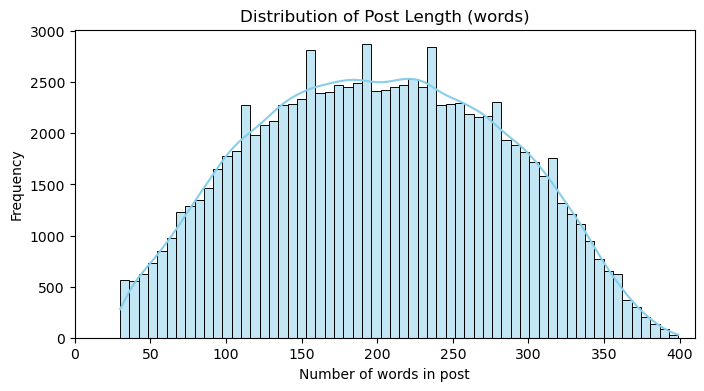

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(df["len_post_words"], bins=60, color="skyblue", kde=True)
plt.title("Distribution of Post Length (words)")
plt.xlabel("Number of words in post")
plt.ylabel("Frequency")
plt.xlim(0, 410)
plt.show()


#### Distirbution of TL;DR Length

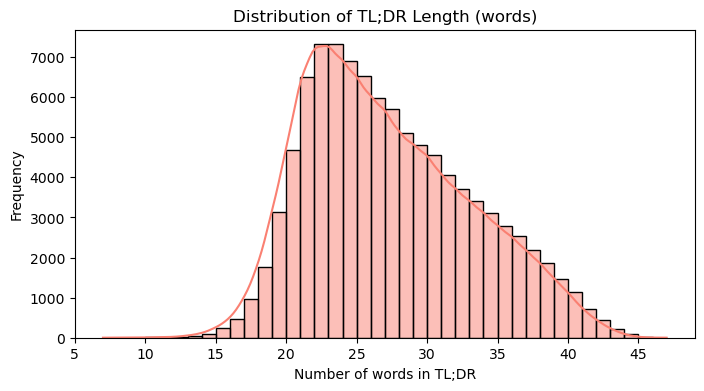

In [16]:
plt.figure(figsize=(8,4))
sns.histplot(df["len_tldr_words"], bins=40, color="salmon", kde=True)
plt.title("Distribution of TL;DR Length (words)")
plt.xlabel("Number of words in TL;DR")
plt.ylabel("Frequency")
plt.show()


#### Compression Ratio (TL;DR length / Post length)

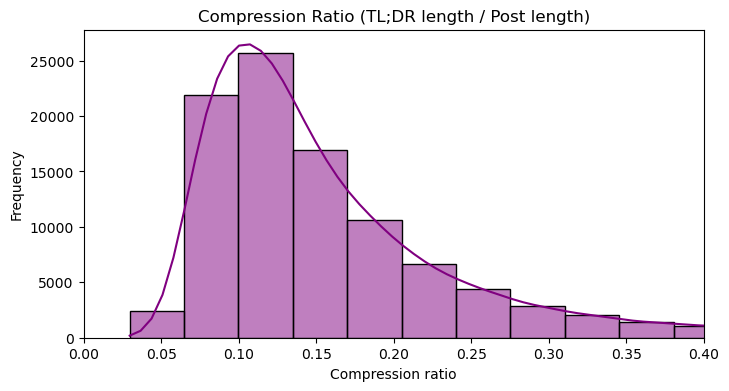

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df["compression_ratio"], bins=40, color="purple", kde=True)
plt.title("Compression Ratio (TL;DR length / Post length)")
plt.xlabel("Compression ratio")
plt.ylabel("Frequency")
plt.xlim(0, 0.4)
plt.show()


#### Subreddits

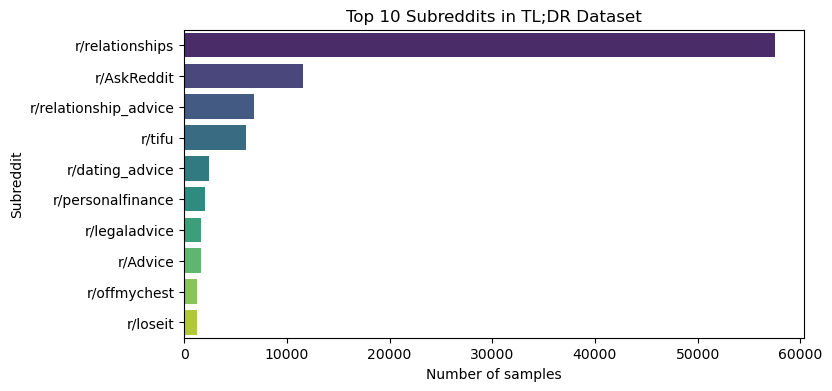

In [21]:
sub_counts = df["subreddit"].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=sub_counts.values,
    y=sub_counts.index,
    hue=sub_counts.index, 
    palette="viridis",
    legend=False           
)
plt.title("Top 10 Subreddits in TL;DR Dataset")
plt.xlabel("Number of samples")
plt.ylabel("Subreddit")
plt.show()
